In [18]:
import pandas as pd
import numpy as np
import plotly.express as px
from pathlib import Path

In [19]:
SCRIPTS = Path.cwd()
DATA = SCRIPTS.parent / "data"

In [20]:
acc_file = "joel_appal_acc_260609_1014.csv"
ecg_file = "joel_appal_ecg_260609_1014.csv" 

acc_df = pd.read_csv(DATA / acc_file)
ecg_df = pd.read_csv(DATA / ecg_file)

In [21]:
ecg_df.shape, acc_df.shape

((8103, 7), (12816, 9))

In [22]:
ecg_df.head(), acc_df.head()

(   packet_id  device_time_ms  host_time_ms  ecg  sample_idx  sample_time_ms  \
 0          0    5.996179e+11  1.780993e+12 -333           0    5.996179e+11   
 1          0    5.996179e+11  1.780993e+12 -333           1    5.996179e+11   
 2          0    5.996179e+11  1.780993e+12 -329           2    5.996179e+11   
 3          0    5.996179e+11  1.780993e+12 -333           3    5.996179e+11   
 4          0    5.996179e+11  1.780993e+12 -331           4    5.996179e+11   
 
      time_ms  
 0   0.000000  
 1   7.692383  
 2  15.384644  
 3  23.076904  
 4  30.769287  ,
    packet_id  device_time_ms  host_time_ms   x    y    z  sample_idx  \
 0          0    5.996179e+11  1.780993e+12  96 -890 -425           0   
 1          0    5.996179e+11  1.780993e+12  96 -888 -427           1   
 2          0    5.996179e+11  1.780993e+12  94 -888 -427           2   
 3          0    5.996179e+11  1.780993e+12  93 -893 -429           3   
 4          0    5.996179e+11  1.780993e+12  95 -890 -43

In [23]:
ecg_df = ecg_df.sort_values("time_ms")
acc_df = acc_df.sort_values("time_ms")

recording = pd.merge_asof(
    ecg_df,
    acc_df[["time_ms", "x", "y", "z"]],
    on="time_ms",
    direction="nearest"
)
recording = recording[["time_ms", "ecg", "x", "y", "z"]]
recording["acc_mag"] = np.sqrt(
    recording["x"]**2 +
    recording["y"]**2 +
    recording["z"]**2)

In [24]:
recording

,time_ms,ecg,x,y,z,acc_mag
0,0.000000,-333,96,-890,-425,990.929362
1,7.692383,-333,94,-888,-427,989.802506
2,15.384644,-329,93,-893,-429,995.057285
3,23.076904,-333,92,-890,-445,999.294251
4,30.769287,-331,93,-893,-439,999.409326
...,...,...,...,...,...,...
8098,62302.765015,-241,-119,-713,-681,993.121845
8099,62310.457397,-225,-147,-700,-653,968.513294
8100,62318.149658,-216,-174,-693,-657,970.656479
8101,62325.842041,-209,-191,-701,-694,1004.747730


In [25]:
import neurokit2 as nk

fs = 130

_, info = nk.ecg_peaks(
    recording["ecg"],
    sampling_rate=fs
)

rpeaks = info["ECG_R_Peaks"]

recording["r_peak"] = 0
recording.loc[rpeaks, "r_peak"] = 1

In [26]:
recording

,time_ms,ecg,x,y,z,acc_mag,r_peak
0,0.000000,-333,96,-890,-425,990.929362,0
1,7.692383,-333,94,-888,-427,989.802506,0
2,15.384644,-329,93,-893,-429,995.057285,0
3,23.076904,-333,92,-890,-445,999.294251,0
4,30.769287,-331,93,-893,-439,999.409326,0
...,...,...,...,...,...,...,...
8098,62302.765015,-241,-119,-713,-681,993.121845,0
8099,62310.457397,-225,-147,-700,-653,968.513294,0
8100,62318.149658,-216,-174,-693,-657,970.656479,0
8101,62325.842041,-209,-191,-701,-694,1004.747730,0


In [27]:
segment = recording.query(
    "20000 <= time_ms <= 30000"
)

peaks = segment[segment["r_peak"] == 1]

fig = px.line(
    segment,
    x="time_ms",
    y="ecg"
)

fig.add_scatter(
    x=peaks["time_ms"],
    y=peaks["ecg"],
    mode="markers",
    name="R peaks"
)

fig.show()

In [28]:
import numpy as np
import pandas as pd

# R-peak times
rpeak_times = recording.loc[recording["r_peak"] == 1, "time_ms"].to_numpy()

# -----------------------------
# 1) Beat-to-beat HR / HRV
# -----------------------------
rr_ms = np.diff(rpeak_times)

hrv_df = pd.DataFrame({
    "time_ms": rpeak_times[1:],
    "rr_ms": rr_ms,
    "bpm_instant": 60000 / rr_ms
})

# -----------------------------
# 2) 1-second sport-watch-like BPM
# -----------------------------
bpm_df = (
    hrv_df
    .set_index(pd.to_timedelta(hrv_df["time_ms"], unit="ms"))
    .resample("1s")
    .mean(numeric_only=True)
    .interpolate()
    .reset_index(drop=True)
)

bpm_df["time_ms"] = np.arange(len(bpm_df)) * 1000
bpm_df["bpm"] = bpm_df["bpm_instant"].rolling(
    window=5,
    center=True,
    min_periods=1
).mean()

bpm_df = bpm_df[["time_ms", "bpm"]]

In [29]:
px.line(
    hrv_df,
    x="time_ms",
    y="rr_ms",
    title="RR Intervals Over Time"
)

In [30]:
px.line(
    bpm_df,
    x="time_ms",
    y="bpm",
    title="BPM Over Time"
)

In [31]:
px.line(
    hrv_df,
    x="time_ms",
    y="rr_ms",
    title="RR Intervals Over Time"
)

In [32]:
rr = hrv_df["rr_ms"]

px.scatter(
    x=rr[:-1],
    y=rr[1:],
    title="Poincaré of RR Intervals",
    labels={"x": "RR(n) [ms]", "y": "RR(n+1) [ms]"}
)

In [33]:
rr_diff = np.diff(hrv_df["rr_ms"])

hrv_df["rmssd_30"] = (
    pd.Series(rr_diff**2)
    .rolling(30)
    .mean()
    .pow(0.5)
)

px.line(
    hrv_df.iloc[1:],
    x="time_ms",
    y="rmssd_30",
    title="HRV Over Time"
)

<Axes: >

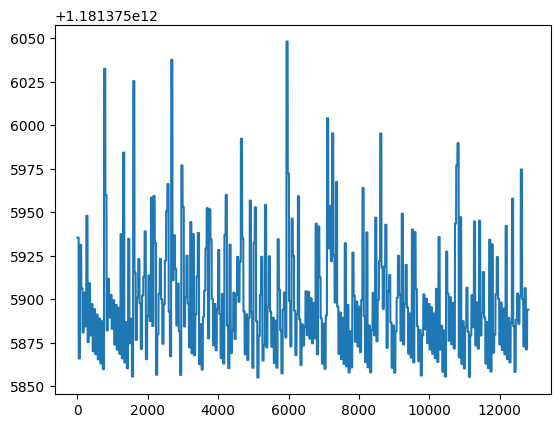

In [38]:
acc_df["delta_time"] = acc_df["host_time_ms"] - acc_df["device_time_ms"]
acc_df["delta_time"].plot()